Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Accuracy: 0.7837837837837838
F1 Score: 0.8518518518518519
Recall Score: 0.9583333333333334
Precision Score: 0.7666666666666667
Confusion Matrix:
[[ 30  35]
 [  5 115]]


C:\Users\kshit\AppData\Local\Temp\ipykernel_22084\3129701578.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object"):


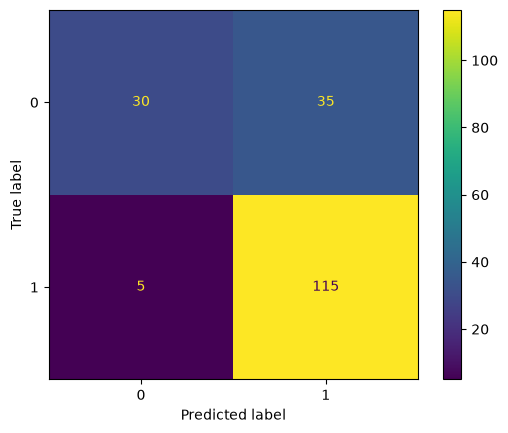

In [ ]:
#===================================================#
# Date : 1st Sept 2026                              #
# Name : Kshitij Shinde                             #
# Roll_no : 60                                      #
# Exam : Mid_Term Lab                               #
# Topic : Naive Bayes  (Assgniment 4)               #
# Dataset : loan_data.csv                       #
#===================================================#

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score , recall_score, precision_score ,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("loan_data.csv")

print(df.isnull().sum())

for c in df.select_dtypes(include="object"):
    df[c] = df[c].fillna(df[c].mode()[0])

for c in df.select_dtypes(exclude="object"):
    df[c] = df[c].fillna(df[c].median())

df["Dependents"] = df["Dependents"].replace("3+", "3")


df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

df.drop("Loan_ID", axis=1, inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

dis = ConfusionMatrixDisplay(confusion_matrix=cm)
dis.plot()
plt.show()